EDA stats is the way to find out :

1. where is the center of data?
2. how spread out is the data?
3. are there unusual values(outliers)?

central tendency-
central tendancy describes that the central or typical value of the data set.

mean - average
median -middle value

In [2]:
import pandas as pd

data = {
"Salesperson": ["Asha","Asha","Asha","Asha","Asha",
                "Bala","Bala","Bala","Bala","Bala",
                "Chitra","Chitra","Chitra","Chitra","Chitra",
                "Deepa","Deepa","Deepa","Deepa","Deepa",
                "Esha","Esha","Esha","Esha","Esha",
                "Farhan","Farhan","Farhan","Farhan","Farhan"],

"Hours_Worked":[6,7,8,6,9,7,8,6,7,8,5,6,7,5,6,8,9,7,8,10,6,7,6,7,8,5,6,7,8,9],

"Sales":[5000,5500,6200,4800,7000,
         5300,6000,5200,5400,6100,
         4500,4800,5000,4600,4700,
         6200,7000,6500,6800,9000,
         5100,5300,5200,5400,5800,
         4300,4600,4800,5200,5600]
}

df = pd.DataFrame(data)
df

,Salesperson,Hours_Worked,Sales
0,Asha,6,5000
1,Asha,7,5500
2,Asha,8,6200
3,Asha,6,4800
4,Asha,9,7000
5,Bala,7,5300
6,Bala,8,6000
7,Bala,6,5200
8,Bala,7,5400
9,Bala,8,6100


In [ ]:
print("Mean value:",df["Sales"].mean())
print("Median value:",df["Sales"].median())

#there mean>median which means there is a positive skew


#outliers is a value that is out of range or on the extreme side
#mean values are affected by outliers
#median value is not affected by outliers




Mean value: 5563.333333333333
Median value: 5300.0


In [ ]:
#Dispersion or spread of data
#Range= max-min

range1=df["Sales"].max()-df["Sales"].min()
print(range1)
#sales vary across a range of 4700

4700


In [ ]:
#variance
#variance measures how far values deviate from the mean
#variance squares deviations to avoid negative values
variance=df["Sales"].var()
print(variance)
#large variance = data widely spread
#small variance = values are clustered

972747.1264367816


In [ ]:
#standard deviation
#it is the square root of variance
stdv=df["Sales"].std()
print(stdv)
#Typical sales deviates about 986 units from the average
#so most sales values roughly fall between 5563-986 or 5563+986=6549
#most sales will roughly fall between 4577 and 6549

986.2794362840491


from these values we get to interpret that
1. the values are not tightly clustered but not extremely spread either
2. most sales lie between 4600 to 6600
3. the 9000 value in sales is likely an outlier increasing the spread of data
4. the distribution of data here id right-skewed

#Q1  0%
#Q2  50%
#Q3  75%
#Q4  100%

In [ ]:
#outliers detection (IQR method)
#I-Inter, Q-Quartile, R-Range- identifies extreme values

Q1=df["Sales"].quantile(0.25)
Q3=df["Sales"].quantile(0.75)
print("Quartile 1:",Q1)
print("Quartile 3:",Q3)
print(Q1)
print(Q3)

#IQR=Q3-Q1
Iqr=Q3-Q1
print("Interquartile range:",Iqr)

#defining outlier boundaries
#Q3-Q1 describes the spread of the middle 50% of the data,ignoring the extreme tails
#using IQR we fing lower bound and upper bound
LB=Q1-1.5*Iqr
print("Lower bound:",LB)

UB=Q3+1.5*Iqr
print("Upper bound:",UB)
#any values outside the 3000 to 8000 will be called an outlier so 9000 is an outlier
df[(df["Sales"]>8000)|(df["Sales"]<3000)] #detecting outlier data

Quartile 1: 4850.0
Quartile 3: 6075.0
4850.0
6075.0
Interquartile range: 1225.0
Lower bound: 3012.5
Upper bound: 7912.5


,Salesperson,Hours_Worked,Sales
19,Deepa,10,9000


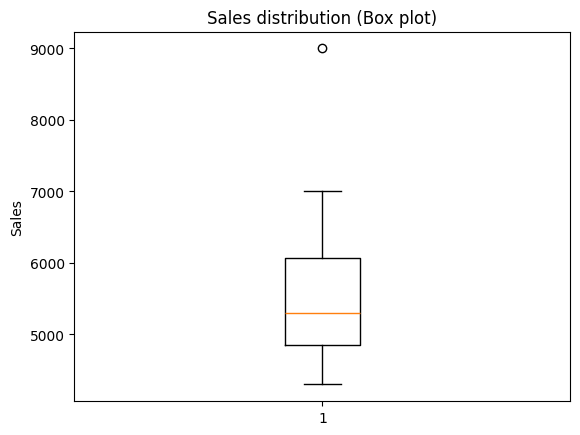

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

data={
    "Sales":[5000,5500,6200,4800,7000,
         5300,6000,5200,5400,6100,
         4500,4800,5000,4600,4700,
         6200,7000,6500,6800,9000,
         5100,5300,5200,5400,5800,
         4300,4600,4800,5200,5600]
}
df=pd.DataFrame(data)
plt.boxplot(df["Sales"])
plt.title("Sales distribution (Box plot)")
plt.ylabel("Sales")
plt.show()


#mean deviation property

1. if you subtract the mean from every data point and add the results the sum is always zero

because:
positive deviations above the mean
negative deviations below the mean cancel each other

2. right skew -> mean>median
   left skew -> mean< median
   symmetric -> mean = median

3. when std dev=0 then it means all values are identical

4. box plot components

box bottom - Q1
line inside box - median
box top - Q3
whiskers - 1.5 * IQR range
dots - outliers

(mean or average value is not usually shown in boxplot unless added manually)

5. if mean is same for two different data and std dev is different then the lower standard deviation = more reliable

6. robust statistics
robust = resistant to outliers
median - resistant/robust value